In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import crosscoders as xc
import torch
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd

import datetime


------------------------- CONSTANTS -------------------------
GlobalsConfig(
    PROJECT_ROOT_DIR = '/home/ec2-user/crosscoders',
    CONFIG_FILEPATH = '/home/ec2-user/crosscoders/src/scripts/configs/train.tiny-stories-33M.yml',
    DATA_DIR = '/home/ec2-user/crosscoders/data',
    EXPERIMENT = ExperimentConfig(
        BATCH_SIZE = 25000,
        MAX_RECORDS = None,
        MAX_BATCHES = 400,
        MAX_TOKENS = 10000000,
        NUM_GPUS = 1,
        NUM_TRAINERS = 1,
        HARDWARE = HardwareConfig(
            dtype = torch.float32,
            device = 'cuda',
        ),
    ),
)
-------------------------------------------------------------



In [3]:
import ray, ray.tune
# from ray import tune


from hyperopt import hp
from ray.tune.search.hyperopt import HyperOptSearch
from ray.tune.schedulers import ASHAScheduler
from ray.tune.progress_reporter import CLIReporter, JupyterNotebookReporter


In [4]:
from src.scripts.train import train_loop_per_worker

from crosscoders import CONSTANTS


In [18]:
from crosscoders.autoencoders.runner import RunnerConfig
from crosscoders.utils import from_dict, get_config, update_dataclass

ray_cfg = {
    'recipe': 'jumprelu',
    'model': {
        'lambda_s': 1
    }
}
runner_cfg = from_dict(
    RunnerConfig,
    get_config(CONSTANTS.CONFIG_FILEPATH).get('RUNNER', {}) | ray_cfg
)


from crosscoders.autoencoders.runner import Runner


runner = Runner(runner_cfg)

runner_cfg

RunnerConfig(
    recipe = 'jumprelu',
    model = JumpReLUModelConfig(
        N_LAYERS = 4,
        D_MODEL = 768,
        D_CODER = 24576,
        lambda_s = 20,
        lambda_p = 3e-06,
        c = 4,
        eps = 2,
        HARDWARE = HardwareConfig(
            dtype = torch.float32,
            device = 'cuda',
        ),
    ),
    OPTIMIZER = OptimizerConfig(
        optimizer = <class 'torch.optim.adam.Adam'>,
        parameters = OptimizerParameters(
            lr = 0.0004,
            betas = (0.9, 0.999),
            fused = True,
        ),
    ),
    INPUT_NAME = 'tiny-stories-33M.ln2.normalized',
    OUTPUT_NAME = 'tiny-stories-33M.mlp_out',
    X_SCALAR = 1.0,
    Y_SCALAR = 1.0,
)

In [6]:
CONSTANTS.EXPERIMENT.MAX_TOKENS = 10000000
CONSTANTS.EXPERIMENT.BATCH_SIZE = 25000
CONSTANTS.EXPERIMENT.MAX_BATCHES = int(np.ceil(CONSTANTS.EXPERIMENT.MAX_TOKENS / CONSTANTS.EXPERIMENT.BATCH_SIZE))
# CONSTANTS.EXPERIMENT.MAX_TOKENS = 5000000

CONSTANTS.EXPERIMENT

ExperimentConfig(
    BATCH_SIZE = 25000,
    MAX_RECORDS = None,
    MAX_BATCHES = 400,
    MAX_TOKENS = 10000000,
    NUM_GPUS = 1,
    NUM_TRAINERS = 1,
    HARDWARE = HardwareConfig(
        dtype = torch.float32,
        device = 'cuda',
    ),
)

In [7]:
from crosscoders.data.dataset import TinyStoriesRayDataset


def reshape(batch):

    for k in batch:
        if k != 'tokens':
            batch[k] = [t.reshape(4, -1) for t in batch[k]]

    return batch




activations_ds = TinyStoriesRayDataset(s3_prefix='tiny-stories-33M/100M-shuffled/').load('activations')
activations_ds = activations_ds.map_batches(reshape)
# activations_ds

2025-02-25 01:52:07,734	WARNING file_meta_provider.py:211 -- Skipping expansion of 10000 path(s). If your paths contain directories or if file size collection is required, try rerunning this read with `meta_provider=DefaultFileMetadataProvider()`.
2025-02-25 01:52:07,762	INFO worker.py:1654 -- Connecting to existing Ray cluster at address: 10.0.1.126:6379...
2025-02-25 01:52:07,774	INFO worker.py:1832 -- Connected to Ray cluster. View the dashboard at http://127.0.0.1:8265 


(pid=2671265) 
(pid=2671265) ------------------------- CONSTANTS -------------------------
(pid=2671265) GlobalsConfig(
(pid=2671265)     PROJECT_ROOT_DIR = '/home/ec2-user/crosscoders',
(pid=2671265)     CONFIG_FILEPATH = '/home/ec2-user/crosscoders/src/scripts/configs/train.tiny-stories-33M.yml',
(pid=2671265)     DATA_DIR = '/home/ec2-user/crosscoders/data',
(pid=2671265)     EXPERIMENT = ExperimentConfig(
(pid=2671265)         BATCH_SIZE = 25000,
(pid=2671265)         MAX_RECORDS = None,
(pid=2671265)         MAX_BATCHES = 400,
(pid=2671265)         MAX_TOKENS = 10000000,
(pid=2671265)         NUM_GPUS = 1,
(pid=2671265)         NUM_TRAINERS = 1,
(pid=2671265)         HARDWARE = HardwareConfig(
(pid=2671265)             dtype = torch.float32,
(pid=2671265)             device = 'cuda',
(pid=2671265)         ),
(pid=2671265)     ),
(pid=2671265) )
(pid=2671265) -------------------------------------------------------------
(pid=2671265) 
(train_loop_per_worker pid=2671265) RunnerConfi

(train_loop_per_worker pid=2671265) Starting execution of Dataset. Full logs are in /tmp/ray/session_2025-02-24_20-04-50_057664_4441/logs/ray-data
(train_loop_per_worker pid=2671265) Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquetBulk] -> LimitOperator[limit=10000000] -> TaskPoolMapOperator[MapBatches(reshape)]
(train_loop_per_worker pid=2671265) Checkpoint successfully created at: Checkpoint(filesystem=s3, path=crosscoders/ray/mats/tune/Tuner_2025-02-25_01:52:08/train_loop_per_worker_1f84e_00000_0_recipe=baseline_2025-02-25_01-52-09/checkpoint_000000)


(train_loop_per_worker pid=2671265) {'training_iteration': 10000000, 'loss': 321.414794921875, 'explained_variance': 0.3741334080696106, 'dead_neurons.all_tokens': 0.0, 'dead_neurons.one_token': 0.01302083395421505, 'dead_neurons.no_token': 0.9869791865348816, 'error': 262.6510009765625, 'l0': 8.178159713745117, 'l1': 29.381895065307617, 'lr': 4.999999999999983e-06, 'lambda_s': 2.0}
(pid=3049942) 
(pid=3049942) ------------------------- CONSTANTS -------------------------
(pid=3049942) GlobalsConfig(
(pid=3049942)     PROJECT_ROOT_DIR = '/home/ec2-user/crosscoders',
(pid=3049942)     CONFIG_FILEPATH = '/home/ec2-user/crosscoders/src/scripts/configs/train.tiny-stories-33M.yml',
(pid=3049942)     DATA_DIR = '/home/ec2-user/crosscoders/data',
(pid=3049942)     EXPERIMENT = ExperimentConfig(
(pid=3049942)         BATCH_SIZE = 25000,
(pid=3049942)         MAX_RECORDS = None,
(pid=3049942)         MAX_BATCHES = 400,
(pid=3049942)         MAX_TOKENS = 10000000,
(pid=3049942)         NUM_GPUS 

(train_loop_per_worker pid=3049942) Starting execution of Dataset. Full logs are in /tmp/ray/session_2025-02-24_20-04-50_057664_4441/logs/ray-data
(train_loop_per_worker pid=3049942) Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquetBulk] -> LimitOperator[limit=10000000] -> TaskPoolMapOperator[MapBatches(reshape)]
(train_loop_per_worker pid=3049942) Checkpoint successfully created at: Checkpoint(filesystem=s3, path=crosscoders/ray/mats/tune/Tuner_2025-02-25_03:02:26/train_loop_per_worker_f1f3b_00000_0_recipe=jumprelu_2025-02-25_03-02-27/checkpoint_000000)


(train_loop_per_worker pid=3049942) {'training_iteration': 10000000, 'loss': 219111.53125, 'explained_variance': 0.7779433727264404, 'dead_neurons.all_tokens': 0.0, 'dead_neurons.one_token': 0.2420654296875, 'dead_neurons.no_token': 0.7579345703125, 'error': 158093.59375, 'l0': 1996.2384033203125, 'l1': 1994.7333984375, 'lp': 1056.1636962890625, 'lr': 4.999999999999983e-06, 'lambda_s': 20.0}


In [8]:

import json
import boto3


def get_stats(bucket, prefix):

    content_object = boto3.resource('s3') \
        .Object(bucket, prefix)

    # return content_object

    file_content = content_object.get()['Body'].read().decode('utf-8')
    stats = json.loads(file_content)

    return stats



stats = get_stats('crosscoders', 'input/roneneldan/TinyStories/train/tiny-stories-33M/stats/100M.json')
stats

{'tiny-stories-33M.ln2.normalized': 110.84573177929444,
 'tiny-stories-33M.mlp_out': 41.29872735536114}

In [ ]:
from typing import Literal


def get_data_scalars(type: Literal['overall', 'layers'], n_layers=4):

    match type:
        case 'overall':
            return {
                'X_SCALAR': np.sqrt(CONSTANTS.EXPERIMENT.MAX_TOKENS) / stats[runner_cfg.INPUT_NAME],
                'Y_SCALAR': np.sqrt(CONSTANTS.EXPERIMENT.MAX_TOKENS) / stats[runner_cfg.OUTPUT_NAME],
            }

        case 'layers':
            return {
                k: torch.tensor(v, **CONSTANTS.EXPERIMENT.HARDWARE.asdict(), requires_grad=False)
                for k, v in {
                    'X_SCALAR': [np.sqrt(CONSTANTS.EXPERIMENT.MAX_TOKENS * n_layers) / stats[runner_cfg.INPUT_NAME][i] for i in range(n_layers)],
                    'Y_SCALAR': [np.sqrt(CONSTANTS.EXPERIMENT.MAX_TOKENS * n_layers) / stats[runner_cfg.OUTPUT_NAME][i] for i in range(n_layers)]
                }.items()
            }

In [ ]:
hps = {
    # 'recipe': ray.tune.grid_search(['baseline', 'jumprelu']),
    'recipe': ray.tune.grid_search(['jumprelu']),

    **get_data_scalars('overall'),
    # 'model': {
    #     'lambda_s': ray.tune.grid_search([10])
    # }
}

In [12]:
tuner = ray.tune.Tuner(
    ray.tune.with_resources(
        # ray.tune.with_parameters(train_loop_per_worker, train_ds=activations_ds, X_SCALAR=stats['tiny-stories-33M.ln2.normalized']),
        ray.tune.with_parameters(train_loop_per_worker, train_ds=activations_ds),
        {'gpu': 1}
    ),
    param_space=hps,
    # tune_config=ray.tune.TuneConfig(
    #     num_samples=1,
    #     scheduler = ASHAScheduler(
    #         time_attr='n_tokens',
    #         metric='loss',
    #         mode='min',
    #         # metric='explained_variance',
    #         # mode='max',
    #         max_t=20000000,
    #         # grace_period=200000,
    #     ),
    #     # search_alg=HyperOptSearch(hps, metric='loss', mode='min')
    # ),
    run_config=ray.tune.RunConfig(
        name=f'Tuner_{datetime.datetime.now(datetime.UTC).strftime("%Y-%m-%d_%H:%M:%S")}',
        storage_path='s3://crosscoders/ray/mats/tune',
        progress_reporter=JupyterNotebookReporter(
            metric_columns=[
                # 'n_tokens',
                'lr',
                'lambda_s',
                'loss',
                'error',
                # 'l1',
                'l0',
                'explained_variance',
                # 'dead_neurons/one_token'
                # 'dead_neurons/no_token'
            ],
            metric='loss',
            mode='min',
            sort_by_metric=True
        )
    ),

)
results = tuner.fit()

2025-02-25 03:02:27,260	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949


(pid=3049942) Running 0: 0.00 row [00:00, ? row/s]

2025-02-25 03:36:36,776	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to 'crosscoders/ray/mats/tune/Tuner_2025-02-25_03:02:26' in 0.4932s.
2025-02-25 03:36:36,780	INFO tune.py:1041 -- Total run time: 2049.52 seconds (2048.74 seconds for the tuning loop).


In [13]:
results

ResultGrid<[
  Result(
    metrics={'loss': 219111.53125, 'explained_variance': 0.7779433727264404, 'dead_neurons.all_tokens': 0.0, 'dead_neurons.one_token': 0.2420654296875, 'dead_neurons.no_token': 0.7579345703125, 'error': 158093.59375, 'l0': 1996.2384033203125, 'l1': 1994.7333984375, 'lp': 1056.1636962890625, 'lr': 4.999999999999983e-06, 'lambda_s': 20.0},
    path='crosscoders/ray/mats/tune/Tuner_2025-02-25_03:02:26/train_loop_per_worker_f1f3b_00000_0_recipe=jumprelu_2025-02-25_03-02-27',
    filesystem='s3',
    checkpoint=Checkpoint(filesystem=s3, path=crosscoders/ray/mats/tune/Tuner_2025-02-25_03:02:26/train_loop_per_worker_f1f3b_00000_0_recipe=jumprelu_2025-02-25_03-02-27/checkpoint_000000)
  )
]>

In [27]:

import os




with results.get_best_result().best_checkpoints[0][0].as_directory() as checkpoint_dir:
    checkpoint_dict = torch.load(os.path.join(checkpoint_dir, "model.pt"))
    runner.model.load_state_dict(checkpoint_dict)

/tmp/ipykernel_2670762/3567180828.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_dict = torch.load(os.path.join(checkpoint_dir, "model.pt"))


In [124]:
batch = activations_ds.take_batch(1000)
{k: v.shape for k, v in batch.items()}

2025-02-25 04:32:20,715	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2025-02-24_20-04-50_057664_4441/logs/ray-data
2025-02-25 04:32:20,716	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquetBulk] -> LimitOperator[limit=10000000] -> TaskPoolMapOperator[MapBatches(reshape)] -> LimitOperator[limit=1000]


Running 0: 0.00 row [00:00, ? row/s]

- ReadParquetBulk 1: 0.00 row [00:00, ? row/s]

- limit=10000000 2: 0.00 row [00:00, ? row/s]

- MapBatches(reshape) 3: 0.00 row [00:00, ? row/s]

- limit=1000 4: 0.00 row [00:00, ? row/s]

{'tokens': (1000,),
 'tiny-stories-33M.ln2.normalized': (1000, 4, 768),
 'tiny-stories-33M.mlp_out': (1000, 4, 768),
 'tiny-stories-33M.resid_post': (1000, 4, 768)}

In [125]:
runner.model.eval()

with torch.inference_mode():

    x     = runner.cfg.X_SCALAR * torch.tensor(batch[runner.cfg.INPUT_NAME], **CONSTANTS.EXPERIMENT.HARDWARE.asdict(), requires_grad=False)
    y     = runner.cfg.Y_SCALAR * torch.tensor(batch[runner.cfg.OUTPUT_NAME], **CONSTANTS.EXPERIMENT.HARDWARE.asdict(), requires_grad=False)
    y_hat = runner.model(x)

In [37]:
import matplotlib.pyplot as plt

In [ ]:
act_stats = {}

datas = {
    'y': y,
    'y_hat': y_hat,
}

for k in datas:

    tld = datas[k].cpu().numpy()

    act_stats[k] = {
        'tl': {'mean': tld.mean(-1), 'std': tld.std(-1)},
        't': {'mean': tld.mean((-2, -1)), 'std': tld.std((-2, -1))},
        'all': {'mean': tld.mean(), 'std': tld.std()}
    }

act_stats

{'y': {'tl': {'mean': array([-1.84634696e-10, -9.72533387e-10, -1.11370435e-11, -1.11580212e-09],
         dtype=float32),
   'std': array([7.23587368e-09, 8.38802894e-09, 1.19482495e-08, 1.89985485e-08],
         dtype=float32)},
  'all': {'mean': -5.774976e-10, 'std': 0.4013503}},
 'y_hat': {'tl': {'mean': array([-8.8981520e-05, -1.7643187e-04, -2.4140358e-05, -4.0178285e-05],
         dtype=float32),
   'std': array([7.1030823e-05, 1.0071093e-04, 1.2791334e-04, 2.5227346e-04],
         dtype=float32)},
  'all': {'mean': -8.2433005e-05, 'std': 0.11346866}}}

In [ ]:
# data = act_stats['y']['tl']['mean']

# layer_order = np.argsort(data, 1)

# layer_ids = np.array([int(''.join(map(str, layer_id + 1))) for layer_id in layer_order])
# tagged = np.hstack([layer_ids[:,None], data])

# tags = np.unique(layer_ids)
# n_tags = len(tags)

AxisError: axis 1 is out of bounds for array of dimension 1

In [137]:
# fig, ax = plt.subplots(n_tags, figsize=(8, 50))

# for i, t in enumerate(tags):

#     data = tagged[(layer_ids == t)][:,1:]

#     ax[i].plot(data.T)
#     # ax[i].set_yscale('log')
#     ax[i].set_xticks(list(range(4)))
#     ax[i].set_title(str(int(t)))

# plt.tight_layout()

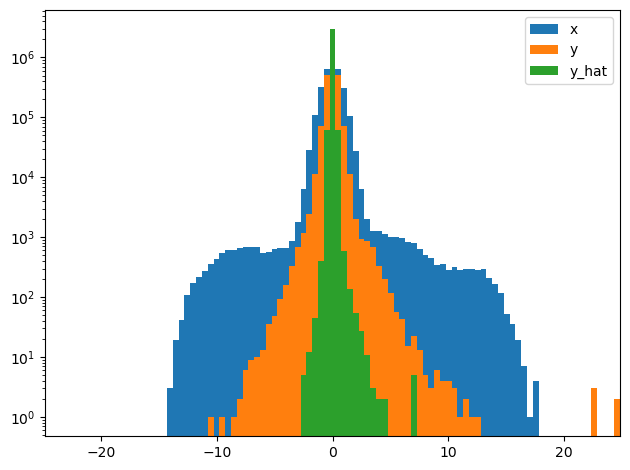

In [ ]:
x_ = x.cpu().numpy()
y_ = y.cpu().numpy()
y_hat_ = y_hat.detach().cpu().numpy()

x_max = max([abs(x_).max(), abs(y_).max(), abs(y_hat_).max()])


bins = np.linspace(-x_max, x_max, 100)
plt.hist(x_.flatten(), bins=bins, label='x')
plt.hist(y_.flatten(), bins=bins, label='y')
plt.hist(y_hat_.flatten(), bins=bins, label='y_hat')


plt.xlim(-x_max, x_max)
plt.yscale('log')

plt.legend()
plt.tight_layout()
plt.show()

In [168]:
y_hat.norm(dim=-1).shape

torch.Size([1000, 4])

In [169]:
from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained('tiny-stories-33M')

Loaded pretrained model tiny-stories-33M into HookedTransformer


In [175]:
logits = model(torch.as_tensor(batch['tokens'], device='cuda')).squeeze(0)
logits.shape

torch.Size([1000, 50257])

In [199]:
def update_forward_pass_hook(model_activations, hook, new_activations):

    # raise NotImplementedError(model_activations.shape, type(hook), new_activations.shape)
    assert model_activations.shape[-2:] == new_activations.shape

    return new_activations.unsqueeze(0)

In [197]:
from functools import partial
from transformer_lens.utils import get_act_name



activations=None
[
    (
        get_act_name('mlp_out', layer_idx),
        partial(update_forward_pass_hook, layer_idx=layer_idx, new_activations=activations)
    )
    for layer_idx in range(model.cfg.n_layers)
]

[('blocks.0.hook_mlp_out',
  functools.partial(<function update_forward_pass_hook at 0x7f2ce19ba480>, layer_idx=0, new_activations=None)),
 ('blocks.1.hook_mlp_out',
  functools.partial(<function update_forward_pass_hook at 0x7f2ce19ba480>, layer_idx=1, new_activations=None)),
 ('blocks.2.hook_mlp_out',
  functools.partial(<function update_forward_pass_hook at 0x7f2ce19ba480>, layer_idx=2, new_activations=None)),
 ('blocks.3.hook_mlp_out',
  functools.partial(<function update_forward_pass_hook at 0x7f2ce19ba480>, layer_idx=3, new_activations=None))]

In [200]:
logits_patched = model.run_with_hooks(
    torch.as_tensor(batch['tokens'], device='cuda'),
    fwd_hooks=[
        (
            get_act_name('mlp_out', layer_idx),
            partial(update_forward_pass_hook, new_activations=y_hat[:,layer_idx,:])
        )
        for layer_idx in range(model.cfg.n_layers)
    ]
)
logits_patched

tensor([[[ 2.0491,  6.2719,  0.3818,  ...,  0.0984,  2.3281,  5.1304],
         [ 3.2239,  7.2544,  0.9720,  ...,  0.5100,  1.7971,  4.6688],
         [ 4.1369,  8.6298, -0.2560,  ..., -0.0905,  0.3795,  6.3496],
         ...,
         [ 8.2066,  6.9013, -0.3252,  ..., -1.5639,  3.1514, 11.2263],
         [12.7928,  8.0671,  2.1807,  ..., -1.5888,  3.9973,  7.4946],
         [ 7.5052,  5.9062, -1.2112,  ..., -1.6932,  1.2616,  8.2340]]],
       device='cuda:0', grad_fn=<ViewBackward0>)

In [ ]:
from torch.nn import functional as F


def jensen_shannon_divergence(logits1, logits2, dim=-1, eps=1e-10):
    """
    Computes the Jensen-Shannon divergence between two sets of logits.

    Args:
        logits1 (Tensor): First tensor of logits.
        logits2 (Tensor): Second tensor of logits.
        dim (int): Dimension along which to compute softmax.
        eps (float): Small value to avoid numerical issues with log(0).

    Returns:
        Tensor: The Jensen-Shannon divergence for each sample.
    """
    # Convert logits to probabilities
    p = F.softmax(logits1, dim=dim)
    q = F.softmax(logits2, dim=dim)

    # Compute the average (midpoint) distribution
    m = 0.5 * (p + q)

    # Compute the KL divergences for each distribution to the midpoint
    kl_pm = torch.sum(p * (torch.log(p + eps) - torch.log(m + eps)), dim=dim)
    kl_qm = torch.sum(q * (torch.log(q + eps) - torch.log(m + eps)), dim=dim)

    # The Jensen-Shannon divergence is the average of these two KL divergences
    js = 0.5 * (kl_pm + kl_qm)
    return js

In [207]:
data = jensen_shannon_divergence(logits, logits_patched)
data = data.squeeze(0).detach().cpu().numpy()
data

array([0.5087959 , 0.57880235, 0.44200304, 0.6206315 , 0.56021476,
       0.6547772 , 0.6563659 , 0.35588294, 0.5429034 , 0.55429316,
       0.59014034, 0.42083815, 0.5729801 , 0.51820153, 0.5352335 ,
       0.46446374, 0.50662184, 0.59684587, 0.6461522 , 0.58854437,
       0.606329  , 0.56870717, 0.5325383 , 0.5172087 , 0.613008  ,
       0.6129295 , 0.39951864, 0.5942019 , 0.6221291 , 0.6402846 ,
       0.6100328 , 0.6330015 , 0.50253904, 0.66021085, 0.64267737,
       0.52807903, 0.3860454 , 0.5789058 , 0.5356901 , 0.39535657,
       0.43734652, 0.6083343 , 0.68891263, 0.49837148, 0.57479835,
       0.30173331, 0.5844829 , 0.6260324 , 0.3493498 , 0.55759764,
       0.54931074, 0.22693284, 0.5683044 , 0.63614154, 0.30530208,
       0.47503787, 0.5751673 , 0.1712831 , 0.6181413 , 0.5790602 ,
       0.3208943 , 0.6095339 , 0.43943235, 0.48122242, 0.3164615 ,
       0.56872064, 0.63789856, 0.62912405, 0.68931067, 0.6467085 ,
       0.4099564 , 0.6157652 , 0.68205315, 0.6347648 , 0.56141

(array([  3.,   1.,  16.,  38.,  49.,  97., 142., 234., 267., 153.]),
 array([0.01777678, 0.08520811, 0.15263945, 0.22007078, 0.28750211,
        0.35493344, 0.42236477, 0.4897961 , 0.55722743, 0.62465876,
        0.69209009]),
 <BarContainer object of 10 artists>)

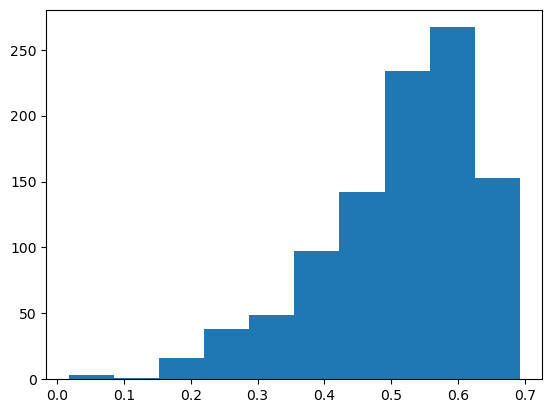

In [208]:
plt.hist(data)

In [213]:
batch['tokens']

array([ 3260,  1842,   373, 13513,   389, 23529,  8288,  4966,  3024,
          11,   198, 15496,  3987,   373,    13,   198,    11,  1320,
         428,   835,   804,  7668,   339,  1011,  1256,   284,  7301,
         422,   281,   290,   804, 14477,   788,   198,  5417,    40,
        2936,   198,   523,  5445,    11,   464,   284, 21874,   607,
         765,   373,    12,  1448,   351,   632, 10421,   290,   290,
          13,   788,   343,    13,   129,  6766,    13, 14350,    13,
         257,  1139,   366,    13,    13,  2402,   373,    13,   887,
         262,   373,  2241,   340,   319,  1049,  2933,   351,   220,
         467, 37413,   336,  3521,  3105,   290,   284,  1257,    13,
         262,   262,  3996,   423,   484, 19177,   373,    11,  7471,
        1319,  1701,   553,  1043,   257,  1375,  3214,     0,  1445,
        3952,    11,  1422,   550, 28633,   262,   284,  2491,   339,
         262,   284,   257,  8359,  6204, 38582,   290,   290,  6151,
          13,  2993,

In [220]:
token_ranking = (((-logits_patched).argsort(-1).squeeze(0).detach().cpu().numpy() == batch['tokens'][:,None])).argmax(-1)

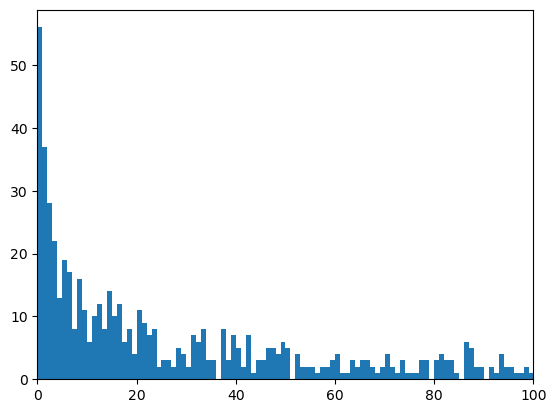

In [230]:
max_rank = 100

bins = np.linspace(0, max(token_ranking), max_rank + 1)
bins = np.linspace(0, max_rank, max_rank + 1)

plt.hist(token_ranking, bins=bins)
plt.xlim(0, max_rank)
plt.show()

In [234]:
# x_enc viz

h = runner.model.x_enc.detach().cpu().numpy()

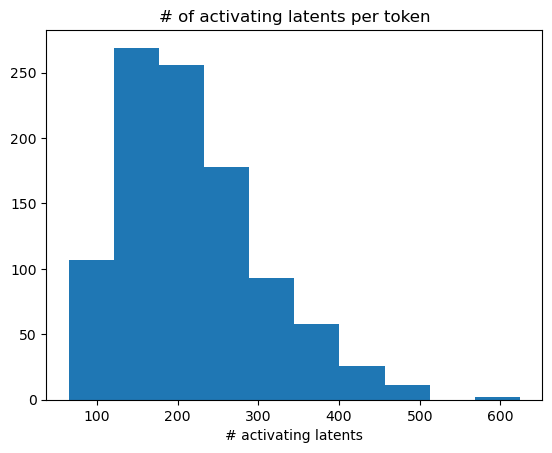

In [256]:
plt.hist((h > 0).sum(-1))
plt.title('# of activating latents per token')
plt.xlabel('# activating latents')
plt.show()

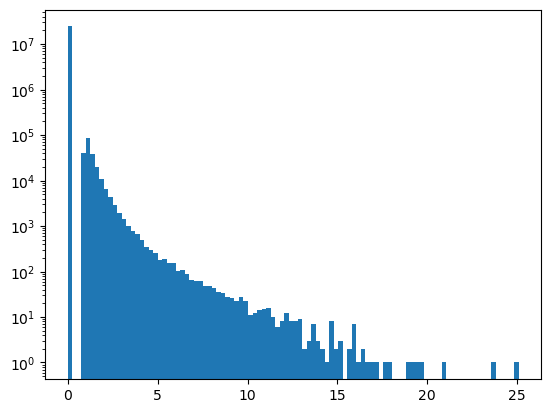

In [260]:
plt.hist(h.flatten(), bins=100)
plt.yscale('log')
plt.show()

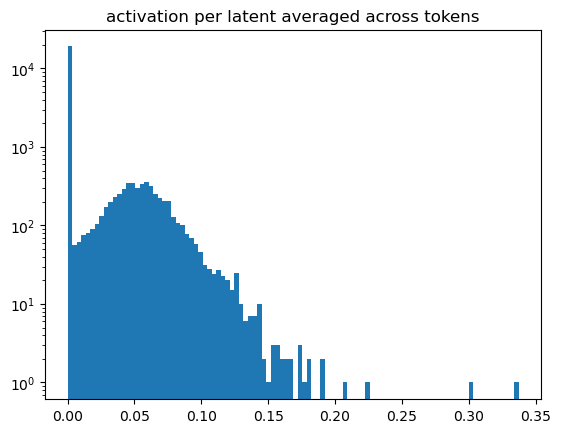

In [262]:
plt.hist(h.mean(0), bins=100)
plt.yscale('log')
plt.title('activation per latent averaged across tokens')
plt.show()

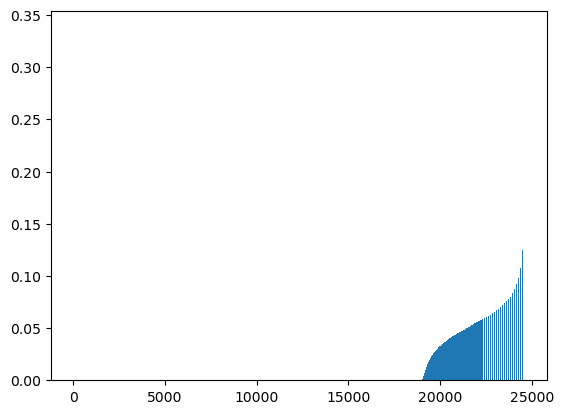

In [267]:
plt.bar(range(h.shape[1]), sorted(h.mean(0)))
# plt.yscale('log')
# plt.title('activation per latent averaged across tokens')
plt.show()

In [236]:
W_dec = runner.model.W_dec.detach().cpu().numpy()

In [ ]:
def cosine_similarity(u, v, axis=-1, eps=1e-10):
    """
    Computes the cosine similarity between two arrays along the specified axis.

    Args:
        u, v: NumPy arrays of the same shape.
        axis: The axis along which to compute the similarity.
        eps: A small constant to avoid division by zero.

    Returns:
        A NumPy array containing the cosine similarities.
    """
    dot_product = np.sum(u * v, axis=axis)
    norm_u = np.linalg.norm(u, axis=axis)
    norm_v = np.linalg.norm(v, axis=axis)
    return dot_product / (norm_u * norm_v + eps)

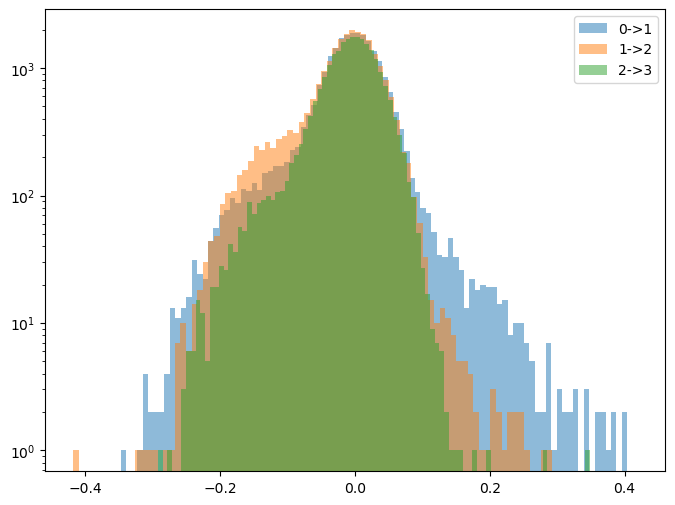

In [253]:
data = cosine_similarity(W_dec[:,:-1], W_dec[:,1:])
# data

fig, ax = plt.subplots(figsize=(8, 6))

for i in range(3):
    data_ = data[:,i]
    x_max = np.abs(data_).max()
    bins = np.linspace(-x_max, x_max, 101)
    ax.hist(data_, bins=bins, alpha=0.5, label=f'{i}->{i+1}')


plt.yscale('log')
plt.legend()
plt.show()